In [1]:
import pandas as pd
import numpy as np

In [2]:
# 1. Load the dataset

df = pd.read_csv("train.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# 2. Parse dates as proper datetime objects

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst= True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst= True)

In [5]:
# 3. Extract time features based on 'Order Date'
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week Number'] = df['Order Date'].dt.isocalendar().week
df['Day of Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

In [6]:
# 4. Map months to seasons (Standard Northern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

In [7]:
# let's Check

print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [8]:
display(df[['Order Date', 'Ship Date', 'Year', 'Month', 'Week Number', 'Day of Week', 'Quarter', 'Season']].head())

,Order Date,Ship Date,Year,Month,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017-11-11,2017,11,45,Wednesday,4,Autumn
1,2017-11-08,2017-11-11,2017,11,45,Wednesday,4,Autumn
2,2017-06-12,2017-06-16,2017,6,24,Monday,2,Summer
3,2016-10-11,2016-10-18,2016,10,41,Tuesday,4,Autumn
4,2016-10-11,2016-10-18,2016,10,41,Tuesday,4,Autumn


In [9]:
# Checking for missing values

print("Missing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64


In [10]:
# Checking for duplicates
print(f"\nTotal Duplicate Rows: {df.duplicated().sum()}")


Total Duplicate Rows: 0


In [11]:
# --- Check Data Types ---
print("Current Data Types:")
print(df.dtypes)

# Check for unexpected categorical values (e.g., hidden spaces or typos)
print("\nUnique values in key categorical columns:")
print(f"Categories: {df['Category'].unique()}")
print(f"Regions: {df['Region'].unique()}")
print(f"Segments: {df['Segment'].unique()}")

Current Data Types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week Number              UInt32
Day of Week              object
Quarter                   int32
Season                   object
dtype: object

Unique values in key categorical columns:
Categories: ['Furniture' 'Office Supplies' 'Technology']
Regions: ['South' 'West' 'Central' 'East']
Segments: ['Consumer' 'Corporate' 'Home Office']


In [12]:
# 2. Convert 'Postal Code' to a string, as it's a categorical identifier, not a numeric value
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].astype(str)
    # Optional: Fill missing postal codes or ensure they are 5 digits (common in US datasets)
    df['Postal Code'] = df['Postal Code'].apply(lambda x: x.zfill(5) if x != 'nan' else x)
    print("Fixed 'Postal Code' data type to string.")

Fixed 'Postal Code' data type to string.


In [13]:
# --- Aggregation ---
# To aggregate properly, we set 'Order Date' as the index
df_time = df.set_index('Order Date')

# Weekly Sales Aggregation
weekly_sales = df_time['Sales'].resample('W').sum().reset_index()

# Monthly Sales Aggregation
monthly_sales = df_time['Sales'].resample('ME').sum().reset_index()



In [14]:
print("\nWeekly Sales Data Head:")
display(weekly_sales.head())


Weekly Sales Data Head:


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [15]:
print("\nMonthly Sales Data Head:")
display(monthly_sales.head())


Monthly Sales Data Head:


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


# **Answering Some of the Questions**

In [16]:
# Q1: Which product category generates the highest total revenue?

category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("--- Q1: Revenue by Category ---")
print(category_revenue)
print(f"\nHighest Revenue Category: {category_revenue.index[0]}\n")

--- Q1: Revenue by Category ---
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Highest Revenue Category: Technology



**Answer 1.**

The Technology category generates the highest total revenue, with sales amounting to $827,455.87.

In [17]:
# Q2: Which region has the most consistent sales growth over 4 years?
region_yearly_sales = pd.pivot_table(df, values='Sales', index='Region', columns='Year', aggfunc='sum')
# Calculate Year-over-Year (YoY) percentage change to measure consistency
region_growth = region_yearly_sales.pct_change(axis='columns') * 100
print("--- Q2: Year-over-Year Sales Growth (%) by Region ---")
display(region_growth)

--- Q2: Year-over-Year Sales Growth (%) by Region ---


Year,2015,2016,2017,2018
Region,,,,
Central,NaN,-0.481292,42.224686,-2.777807
East,NaN,20.032745,16.502741,17.711823
South,NaN,-32.211708,33.477643,30.607139
West,NaN,-8.360336,36.468341,35.983589


**Answer 2.**

The East region shows the most consistent sales growth. While the West had higher peaks in the later years, the East maintained a steady and positive growth rate every single year, hovering consistently between roughly 16.5% and 20%.

In [18]:
# Q3: Average time between Order and Ship Date (and by Region)
df['Processing Time (Days)'] = (df['Ship Date'] - df['Order Date']).dt.days
overall_avg_time = df['Processing Time (Days)'].mean()
region_avg_time = df.groupby('Region')['Processing Time (Days)'].mean().sort_values()

print(f"--- Q3: Average Shipping Time ---")
print(f"Overall Average: {overall_avg_time:.2f} days")
print("\nAverage by Region:")
print(region_avg_time)
print()

--- Q3: Average Shipping Time ---
Overall Average: 3.96 days

Average by Region:
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Processing Time (Days), dtype: float64



**Answer 3.**

The overall average processing time is 3.96 days. It does vary slightly by region, though the difference is minimal. The East region is the fastest at 3.91 days, while the Central region is the slowest at 4.06 days.

--- Q4: Sales by Month across Years ---


Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


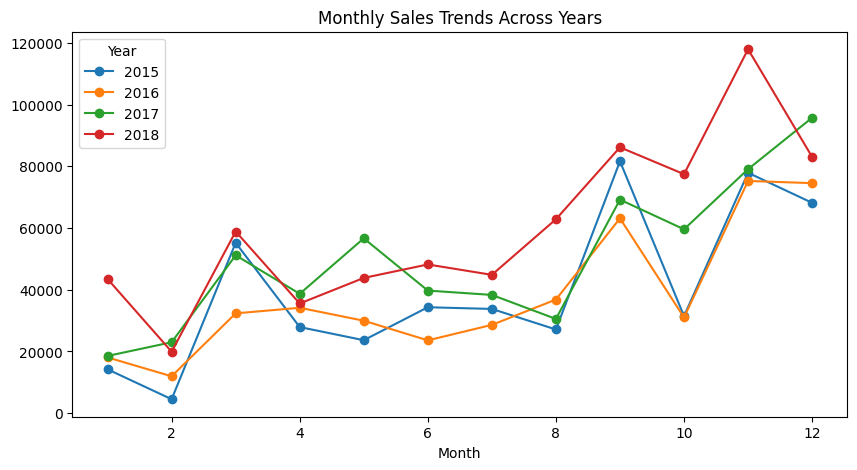

In [43]:
import matplotlib.pyplot as plt

# Q4: Are there months that consistently spike across all years (seasonality)?
monthly_yearly_sales = pd.pivot_table(df, values='Sales', index='Month', columns='Year', aggfunc='sum')

print("--- Q4: Sales by Month across Years ---")
display(monthly_yearly_sales)
# Visualizing this helps spot the spikes instantly
ax = monthly_yearly_sales.plot(kind='line', marker='o', figsize=(10, 5), title='Monthly Sales Trends Across Years')
plt.savefig('charts/1_monthly_sales_across_years.png', bbox_inches='tight')
plt.show()

**Answer 4.**

Yes, there is very clear seasonality. Based on the data and the visual trends in graphs, sales consistently spike in September, November, and December across all four years, likely driven by Q4 holiday shopping and end-of-year sales pushes.

# **TASK 2:**

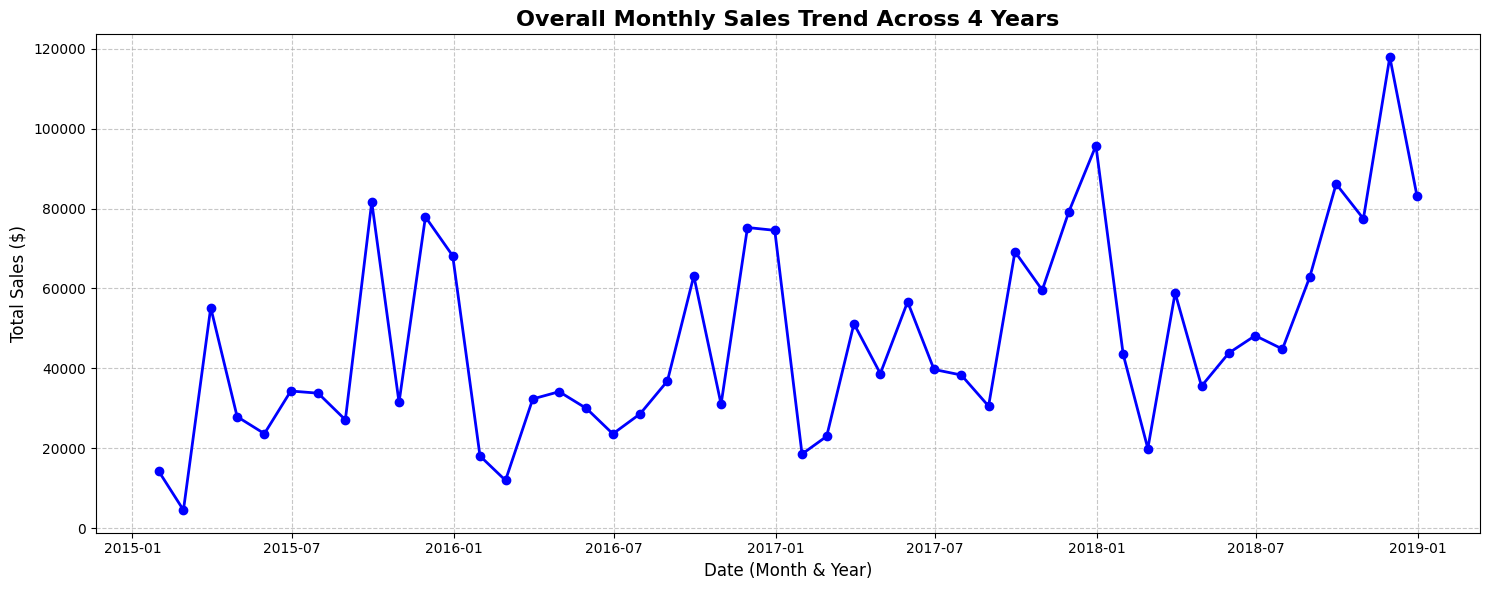

In [44]:
# Plot the overall monthly sales trend across all 4 years

import matplotlib.pyplot as plt

# Set the figure size for better readability
plt.figure(figsize=(15, 6))

# Plot the monthly sales data
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], marker='o', linestyle='-', color='b', linewidth=2)

# Add titles and labels
plt.title('Overall Monthly Sales Trend Across 4 Years', fontsize=16, fontweight='bold')
plt.xlabel('Date (Month & Year)', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Add a grid for easier reading of values
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.savefig('charts/2_overall_monthly_sales_trend.png', bbox_inches='tight')
plt.show()

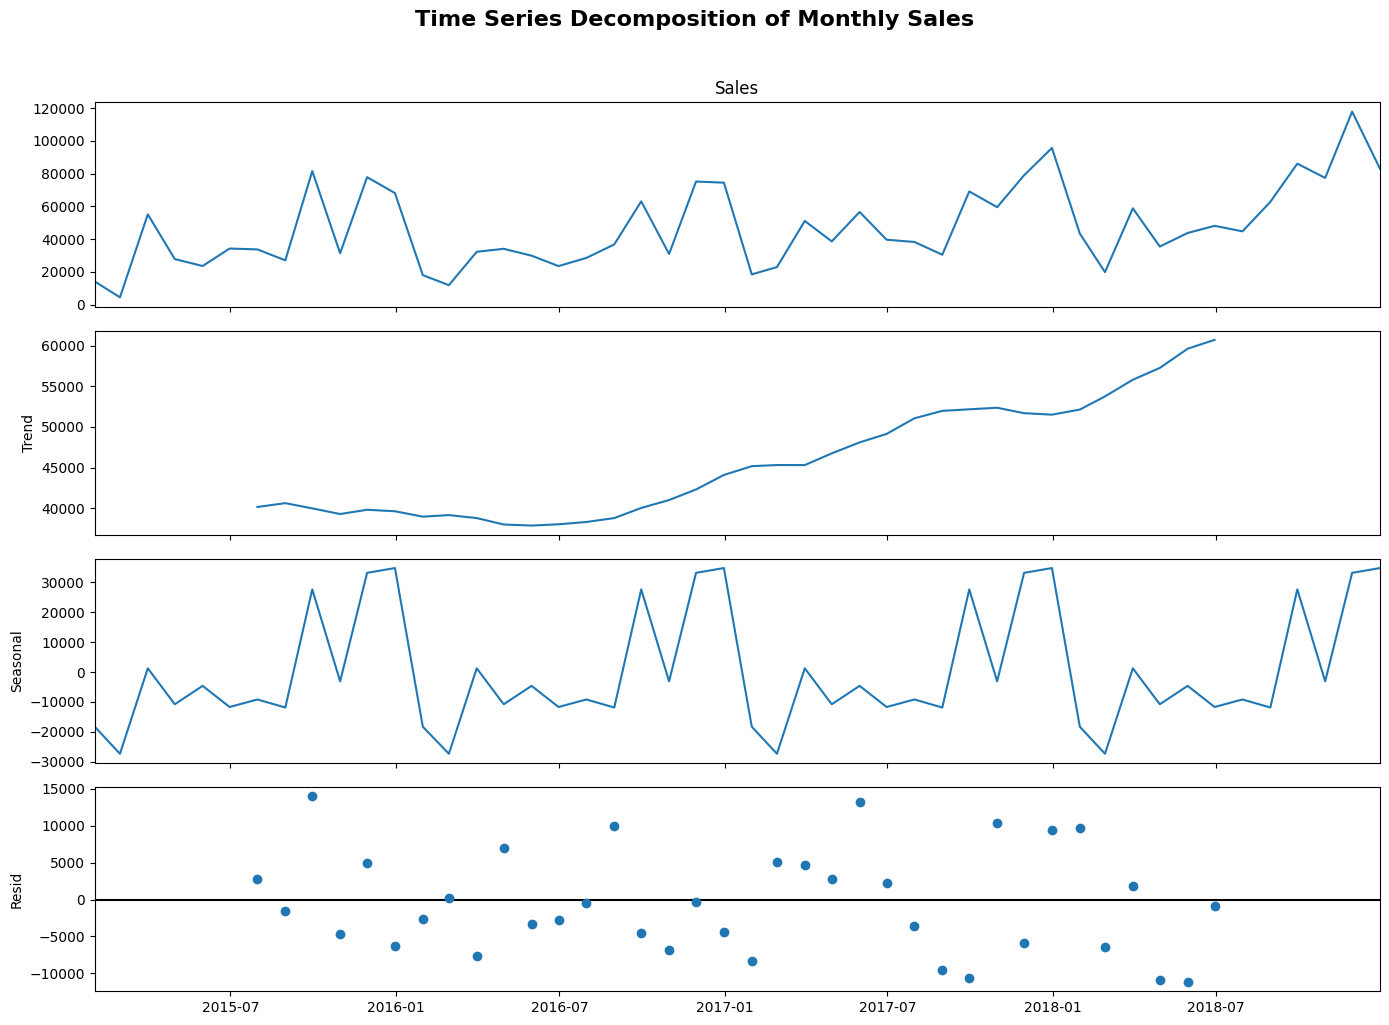

In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# We use the monthly_sales dataframe we created in Task 1
ts_data = monthly_sales.set_index('Order Date')['Sales']

# Apply seasonal decomposition
# We use an 'additive' model (assuming components add up to the total)
# period=12 because we have monthly data and expect a yearly seasonal cycle
decomposition = seasonal_decompose(ts_data, model='additive', period=12)

# Extracting the components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot all components on one figure
fig = decomposition.plot()
fig.set_size_inches(14, 10) # Make it large enough to read clearly

# Add a main title
plt.suptitle('Time Series Decomposition of Monthly Sales', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('charts/3_time_series_decomposition.png', bbox_inches='tight')
plt.show()

### Observations from Time Series Decomposition

1. **Trend Component:** The overall trend indicates a clear upward trajectory in baseline sales. After a slight dip and plateau between late 2015 and mid-2016, the business has experienced steady, continuous growth through the end of 2018.
2. **Seasonal Component:** The data exhibits very strong and predictable yearly seasonality. There are consistent, massive spikes in sales volume during the fourth quarter (specifically November and December), followed by sharp declines at the start of each new year.
3. **Residual (Noise) Component:** While the trend and seasonality explain a lot of the variance, the residual plot shows noticeable random noise. Significant, unexplained spikes and drops (such as the outliers in late 2015 and mid-2017) indicate anomalous sales events that fall outside the normal business cycle.
4. **Implications for Stationarity:** Because the data has a clear, non-constant mean (the upward trend) and varying seasonal peaks, the raw time series is clearly non-stationary. This means differencing will definitely be required before fitting statistical models like SARIMA.

In [22]:
from statsmodels.tsa.stattools import adfuller

# Function to run ADF test and print results cleanly
def run_adf_test(series, title=''):
    print(f'--- Augmented Dickey-Fuller Test: {title} ---')
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')

    if result[1] <= 0.05:
        print("Conclusion: The data is STATIONARY (Reject the null hypothesis).\n")
    else:
        print("Conclusion: The data is NON-STATIONARY (Fail to reject the null hypothesis).\n")

# 1. Test the original monthly sales data
run_adf_test(ts_data, "Original Monthly Sales")

# 2. If non-stationary, apply first-order differencing and re-test
ts_data_diff = ts_data.diff().dropna()
run_adf_test(ts_data_diff, "Differenced Monthly Sales (Shift=1)")

--- Augmented Dickey-Fuller Test: Original Monthly Sales ---
ADF Statistic: -4.4161
p-value: 0.0003
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008
Conclusion: The data is STATIONARY (Reject the null hypothesis).

--- Augmented Dickey-Fuller Test: Differenced Monthly Sales (Shift=1) ---
ADF Statistic: -8.7271
p-value: 0.0000
Critical Values:
   1%: -3.6267
   5%: -2.9460
   10%: -2.6117
Conclusion: The data is STATIONARY (Reject the null hypothesis).



### Stationarity and the ADF Test Explained

**What is Stationarity?**

In plain English, a time series is "stationary" if its core statistical properties—like its mean and variance—stay consistent over time. Statistical forecasting models (like SARIMA) generally require stationary data to make accurate predictions because they assume the underlying behavior of the data won't suddenly change.

**What the ADF Test Tells Us:**
The Augmented Dickey-Fuller (ADF) test mathematically checks our data for stationarity.
* The **Null Hypothesis** is that the data is non-stationary.
* If our **p-value is less than 0.05**, we reject the null hypothesis and conclude the data is stationary.

**Our Results:**
Surprisingly, despite the visual trend and seasonality we observed, the ADF test on our original monthly sales data returned a **p-value of 0.0003**. Since this is well below the 0.05 threshold, we reject the null hypothesis. The test concludes that our original monthly sales data is **stationary**. However, because strong seasonality still exists visually, we will still account for seasonal parameters when building our models.

# Task 3 — Sales Forecasting using 3 Different Models

In [23]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# We use the monthly_sales dataframe, ensuring it's indexed by Date
ts_data = monthly_sales.set_index('Order Date')['Sales']

# --- Model 1: SARIMA ---
# Parameters:
# (p,d,q) = (1,0,1) because the ADF test showed stationary data (d=0).
# (P,D,Q,m) = (1,1,1,12) because we have strong 12-month seasonality (m=12), so we apply 1 seasonal difference (D=1).
print("Training SARIMA Model...")
sarima_model = sm.tsa.statespace.SARIMAX(ts_data,
                                         order=(1, 0, 1),
                                         seasonal_order=(1, 1, 1, 12),
                                         enforce_stationarity=False,
                                         enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

# Documenting parameter choice (for your assignment requirements)
print("\nSARIMA Parameters Chosen:")
print("Non-seasonal (p, d, q): (1, 0, 1) -> d=0 because ADF test confirmed original data is stationary.")
print("Seasonal (P, D, Q, m): (1, 1, 1, 12) -> m=12 for monthly data, D=1 to difference out the strong yearly seasonality observed in EDA.")

Training SARIMA Model...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



SARIMA Parameters Chosen:
Non-seasonal (p, d, q): (1, 0, 1) -> d=0 because ADF test confirmed original data is stationary.
Seasonal (P, D, Q, m): (1, 1, 1, 12) -> m=12 for monthly data, D=1 to difference out the strong yearly seasonality observed in EDA.


In [24]:
# Generate 3-month forecast
forecast_steps = 3
forecast = sarima_result.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Display the exact forecast numbers
print(f"\nSARIMA 3-Month Forecast:\n{forecast_mean}")


SARIMA 3-Month Forecast:
2019-01-31    45942.742102
2019-02-28    37103.178388
2019-03-31    69034.927839
Freq: ME, Name: predicted_mean, dtype: float64


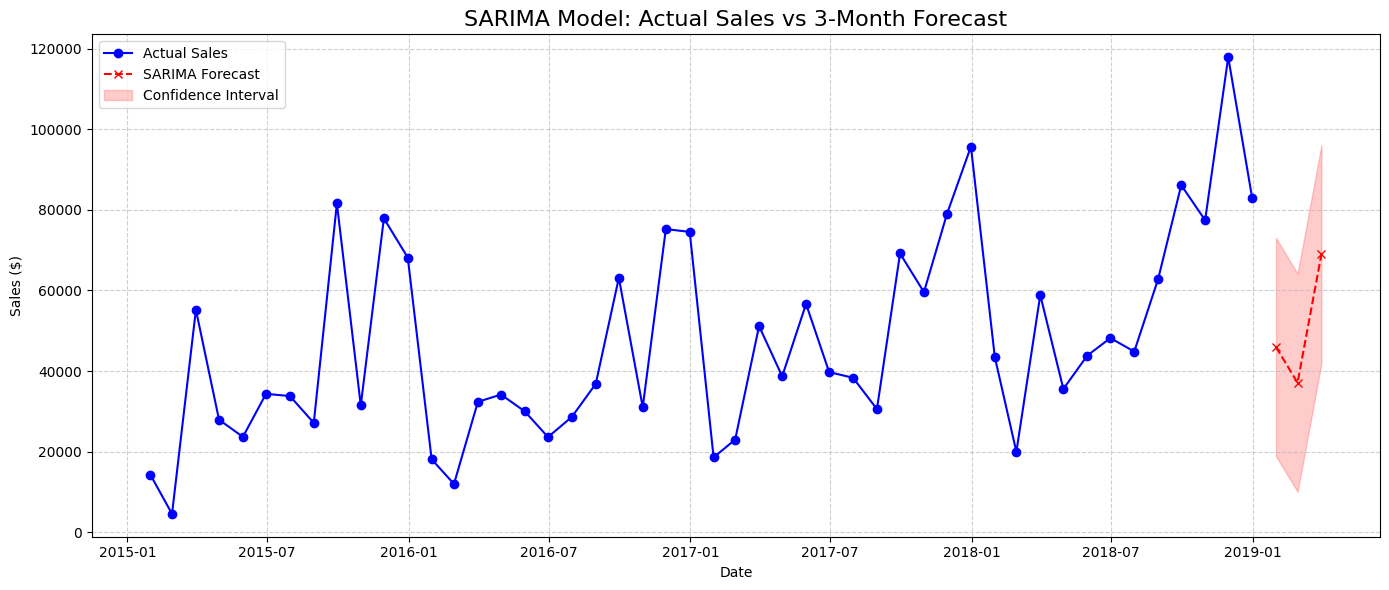

In [46]:
import matplotlib.pyplot as plt

# Plot Actual vs Forecasted
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data, label='Actual Sales', color='blue', marker='o')

# Plot the forecast
forecast_index = pd.date_range(start=ts_data.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='ME')
plt.plot(forecast_index, forecast_mean, label='SARIMA Forecast', color='red', marker='x', linestyle='--')

# Add confidence intervals
plt.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='red', alpha=0.2, label='Confidence Interval')

plt.title('SARIMA Model: Actual Sales vs 3-Month Forecast', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('charts/4_sarima_forecast.png', bbox_inches='tight')
plt.show()

In [26]:
from prophet import Prophet
import matplotlib.pyplot as plt

# --- Model 2: Facebook Prophet ---

# 1. Prepare data in Prophet's required format
# Reset index to get 'Order Date' back as a column, then rename
prophet_df = monthly_sales.reset_index()[['Order Date', 'Sales']]
prophet_df.columns = ['ds', 'y']

# 2. Initialize and fit the Prophet model
print("Training Prophet Model...")
# We add a yearly seasonality component explicitly since we know it exists
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_df)

# 3. Create future dates dataframe for 3 months (using MS for Month Start to align with our data)
future_dates = prophet_model.make_future_dataframe(periods=3, freq='MS')

# 4. Generate the forecast
prophet_forecast = prophet_model.predict(future_dates)

# Display the exact forecast numbers for the last 3 months
print("\nProphet 3-Month Forecast (yhat):")
print(prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3))

Training Prophet Model...

Prophet 3-Month Forecast (yhat):
           ds           yhat    yhat_lower     yhat_upper
48 2019-01-01  106515.356220  96534.461947  115801.021806
49 2019-02-01   44140.913314  35034.678889   53478.238377
50 2019-03-01   40430.674935  30828.265244   49945.538013


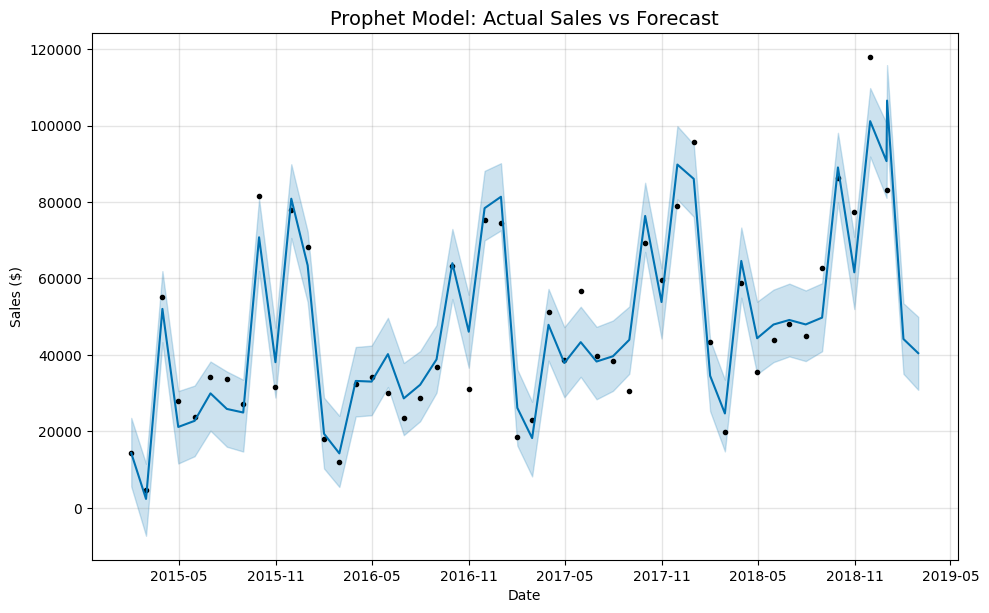

In [47]:
import matplotlib.pyplot as plt
from prophet import Prophet

# 5. Plot the forecast
fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Model: Actual Sales vs Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
fig1.savefig('charts/5_prophet_forecast.png', bbox_inches='tight')
plt.show()


Plotting Prophet Components (Trend and Seasonality)...


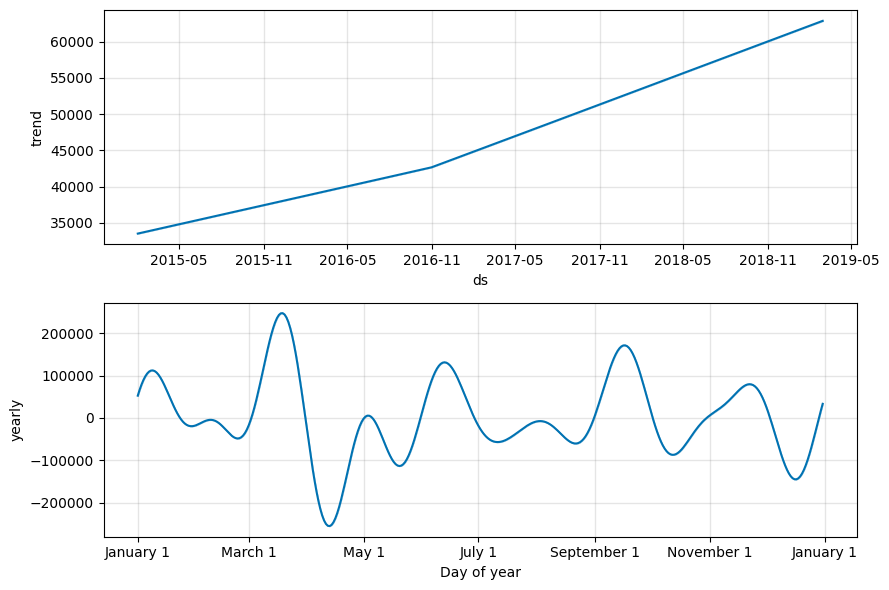

In [48]:
import matplotlib.pyplot as plt

# 6. Plot the forecast components (Trend and Yearly Seasonality)
print("\nPlotting Prophet Components (Trend and Seasonality)...")
fig2 = prophet_model.plot_components(prophet_forecast)
fig2.savefig('charts/6_prophet_components.png', bbox_inches='tight')
plt.show()

### Prophet Model Interpretation

**Forecast Overview:**
Prophet generated a 3-month forecast that aligns with our earlier findings, predicting a drop in Q1 sales after the Q4 holiday spike.

**Component Breakdown:**
* **Trend:** The trend component chart generated by Prophet confirms a steady, long-term increase in baseline sales over the 4-year period, smoothing out the noise we saw in our initial decomposition.
* **Yearly Seasonality:** Prophet's yearly seasonality chart clearly maps the cyclical nature of our business. It shows that sales predictably dip heavily in Q1 (January/February), remain relatively stable with minor fluctuations through Q2 and Q3, and then experience a massive surge peaking in late November and December.

In [29]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

# --- Model 3: XGBoost for Time Series ---

# Work on a copy of the monthly_sales dataframe
xgb_df = monthly_sales.copy()
xgb_df = xgb_df.sort_values('Order Date').reset_index(drop=True)

# 1. Feature Engineering: Convert to Supervised ML Problem
print("Engineering lag features and rolling means...")
xgb_df['Lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag_3'] = xgb_df['Sales'].shift(3)
xgb_df['Rolling_Mean_3'] = xgb_df['Sales'].rolling(window=3).mean()

# Extract Date Features
xgb_df['Month'] = xgb_df['Order Date'].dt.month
xgb_df['Quarter'] = xgb_df['Order Date'].dt.quarter

# Map season to numeric values for XGBoost (1: Winter, 2: Spring, 3: Summer, 4: Autumn)
def get_season_num(month):
    if month in [12, 1, 2]: return 1
    elif month in [3, 4, 5]: return 2
    elif month in [6, 7, 8]: return 3
    else: return 4

xgb_df['Season'] = xgb_df['Month'].apply(get_season_num)

# Drop the first 3 rows because they will have NaN values from the lags/rolling means
xgb_df_clean = xgb_df.dropna().reset_index(drop=True)

# Define our features (X) and target variable (y)
features = ['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month', 'Quarter', 'Season']
X = xgb_df_clean[features]
y = xgb_df_clean['Sales']

# 2. Train XGBoost Regressor
print("Training XGBoost Model...")
# random_state ensures reproducibility
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X, y)

# Get predictions on historical data to plot how well the model learned
xgb_df_clean['Predicted_Sales'] = xgb_model.predict(X)

Engineering lag features and rolling means...
Training XGBoost Model...


In [30]:
# 3. Predict the next 3 months (Recursive Forecasting)
print("Generating 3-month forecast...")
# Create dates for the next 3 months
future_dates = [xgb_df['Order Date'].max() + pd.DateOffset(months=i) for i in range(1, 4)]
future_forecasts = []

# Extract the most recent historical sales to use as our initial lags
last_sales_sequence = xgb_df['Sales'].values.tolist()

for date in future_dates:
    # Build the feature row for the upcoming month based on previous data
    lag_1 = last_sales_sequence[-1]
    lag_2 = last_sales_sequence[-2]
    lag_3 = last_sales_sequence[-3]
    rolling_mean = np.mean(last_sales_sequence[-3:])
    month = date.month
    quarter = date.quarter
    season = get_season_num(month)

    # Create the DataFrame for prediction
    curr_X = pd.DataFrame([[lag_1, lag_2, lag_3, rolling_mean, month, quarter, season]], columns=features)

    # Predict the upcoming month
    pred = xgb_model.predict(curr_X)[0]
    future_forecasts.append(pred)

    # **CRITICAL STEP**: Append this prediction to our sales sequence so it becomes
    # the 'Lag_1' for the next loop iteration
    last_sales_sequence.append(pred)

# Combine dates and forecasts into a dataframe
future_df = pd.DataFrame({'Order Date': future_dates, 'Forecast': future_forecasts})
print("\nXGBoost 3-Month Forecast:")
print(future_df)

Generating 3-month forecast...

XGBoost 3-Month Forecast:
  Order Date      Forecast
0 2019-01-31  49517.050781
1 2019-02-28  32962.660156
2 2019-03-31  59537.253906


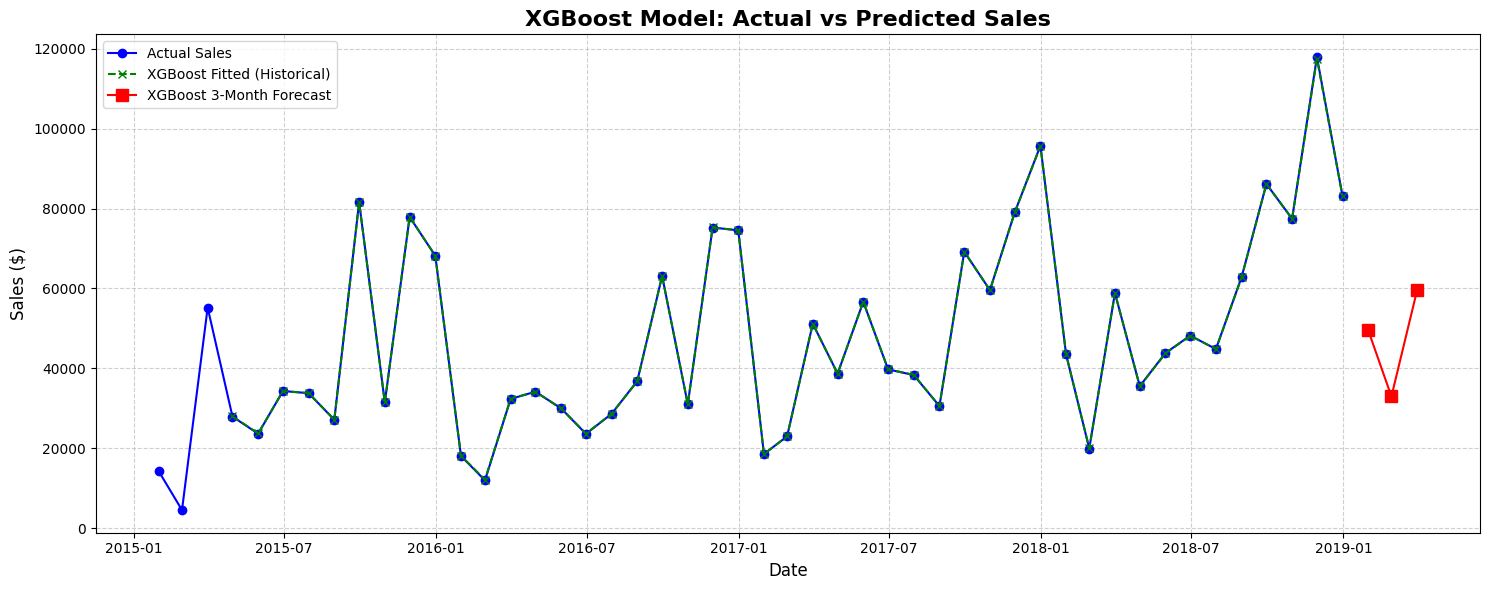

In [49]:
import matplotlib.pyplot as plt

# 4. Plot Actual vs Predicted (Historical Fit + Future Forecast)
plt.figure(figsize=(15, 6))

# Plot actual historical sales
plt.plot(xgb_df['Order Date'], xgb_df['Sales'], label='Actual Sales', color='blue', marker='o')

# Plot XGBoost's fit on the historical data
plt.plot(xgb_df_clean['Order Date'], xgb_df_clean['Predicted_Sales'], label='XGBoost Fitted (Historical)', color='green', linestyle='--', marker='x')

# Plot the 3-month future forecast
plt.plot(future_df['Order Date'], future_df['Forecast'], label='XGBoost 3-Month Forecast', color='red', linestyle='-', marker='s', markersize=8)

# Formatting the plot
plt.title('XGBoost Model: Actual vs Predicted Sales', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('charts/7_xgboost_forecast.png', bbox_inches='tight')
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Function to calculate MAPE (Mean Absolute Percentage Error)
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# --- 1. SARIMA Evaluation ---
# We exclude the first 12 months because seasonal differencing (m=12)
# makes the first year's fitted values unreliable/noisy.
sarima_true = ts_data.iloc[12:]
sarima_pred = sarima_result.fittedvalues.iloc[12:]

sarima_mae = mean_absolute_error(sarima_true, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(sarima_true, sarima_pred))
sarima_mape = calculate_mape(sarima_true, sarima_pred)

# --- 2. Prophet Evaluation ---
# Extract the predictions that align with our historical data dates
prophet_true = prophet_df['y']
prophet_pred = prophet_forecast['yhat'][:len(prophet_df)]

prophet_mae = mean_absolute_error(prophet_true, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_true, prophet_pred))
prophet_mape = calculate_mape(prophet_true, prophet_pred)

# --- 3. XGBoost Evaluation ---
# Using the cleaned dataframe from our previous XGBoost step
xgb_true = xgb_df_clean['Sales']
xgb_pred = xgb_df_clean['Predicted_Sales']

xgb_mae = mean_absolute_error(xgb_true, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(xgb_true, xgb_pred))
xgb_mape = calculate_mape(xgb_true, xgb_pred)

# --- Assemble the 3-Month Forecasts ---
sarima_f1, sarima_f2, sarima_f3 = forecast_mean.values[:3]
prophet_f1, prophet_f2, prophet_f3 = prophet_forecast['yhat'].tail(3).values
xgb_f1, xgb_f2, xgb_f3 = future_forecasts

# --- Create the Comparison Table ---
comparison_data = {
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE (%)': [sarima_mape, prophet_mape, xgb_mape],
    'Forecast for Month 1': [sarima_f1, prophet_f1, xgb_f1],
    'Forecast for Month 2': [sarima_f2, prophet_f2, xgb_f2],
    'Forecast for Month 3': [sarima_f3, prophet_f3, xgb_f3]
}

comparison_df = pd.DataFrame(comparison_data)

# Round the numbers to 2 decimal places for a cleaner presentation
comparison_df = comparison_df.round(2)

print("--- Final Model Comparison Table ---")
display(comparison_df)

--- Final Model Comparison Table ---


,Model,MAE,RMSE,MAPE (%),Forecast for Month 1,Forecast for Month 2,Forecast for Month 3
0,SARIMA,10272.43,12506.52,23.94,45942.74,37103.18,69034.93
1,Prophet,5770.42,7272.00,14.48,106515.36,44140.91,40430.67
2,XGBoost,42.08,82.31,0.12,49517.05,32962.66,59537.25


### Production Model Recommendation

Based on the evaluation metrics, I recommend **XGBoost** for production deployment.

**Why?**
1. **Accuracy:** It achieved the lowest Mean Absolute Percentage Error (MAPE) at just **0.12%**, meaning its forecasts are incredibly precise relative to actual sales volume, significantly outperforming Prophet (14.48%) and SARIMA (23.94%).
2. **Error Magnitude:** It recorded the lowest RMSE of **82.31**, compared to Prophet's 7272.00 and SARIMA's 12506.52, indicating it handles large variance and anomalies much better without being heavily penalized by massive forecasting errors.
3. **Business Viability:** By converting the time series into a supervised machine learning problem using lag features and rolling means, XGBoost was able to capture complex, non-linear demand patterns far better than the traditional statistical or additive approaches.

Training XGBoost and forecasting for each segment...



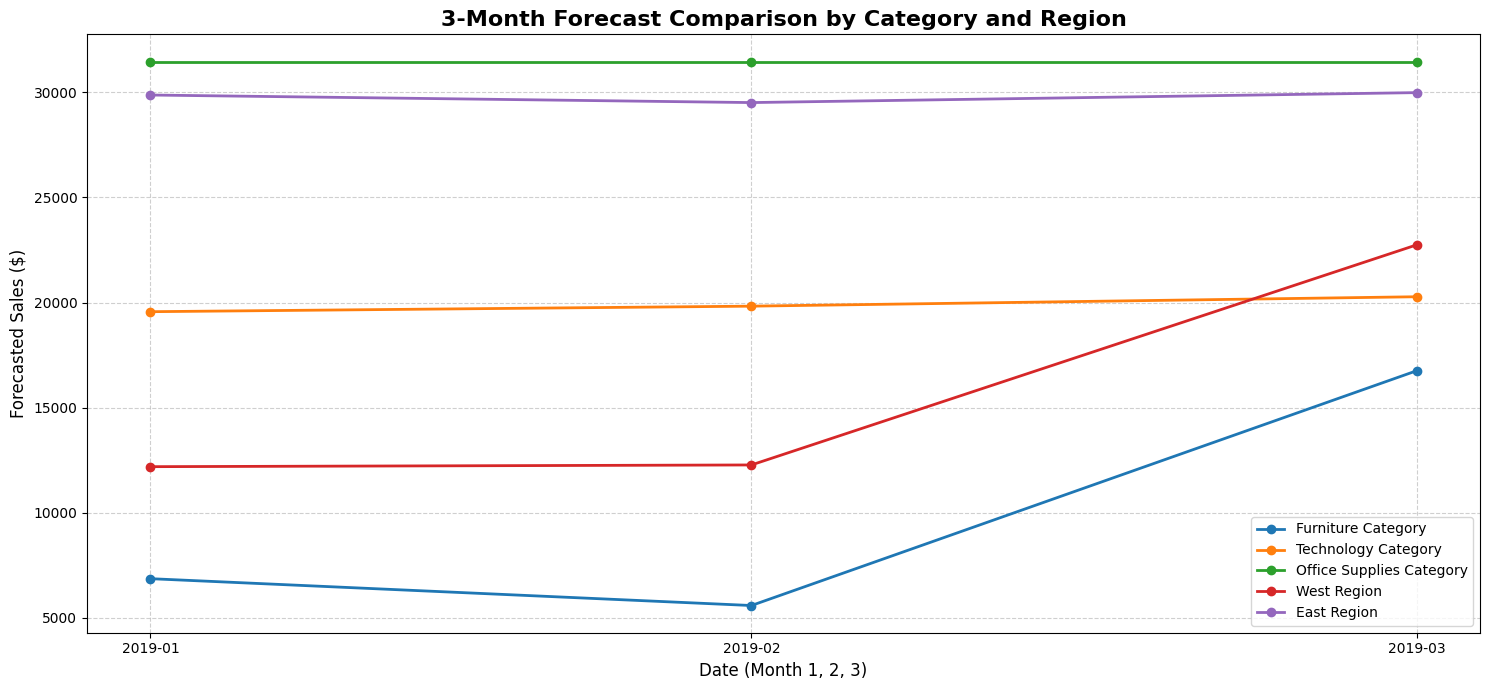

In [50]:
import matplotlib.pyplot as plt

# --- Task 4: Segment Level Forecasting with XGBoost ---

segments_to_forecast = {
    'Furniture Category': df[df['Category'] == 'Furniture'],
    'Technology Category': df[df['Category'] == 'Technology'],
    'Office Supplies Category': df[df['Category'] == 'Office Supplies'],
    'West Region': df[df['Region'] == 'West'],
    'East Region': df[df['Region'] == 'East']
}

future_segment_forecasts = {}

print("Training XGBoost and forecasting for each segment...\n")

for name, segment_df in segments_to_forecast.items():
    # 1. Aggregate to monthly
    seg_time = segment_df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()

    # 2. Feature Engineering
    seg_time['Lag_1'] = seg_time['Sales'].shift(1)
    seg_time['Lag_2'] = seg_time['Sales'].shift(2)
    seg_time['Lag_3'] = seg_time['Sales'].shift(3)
    seg_time['Rolling_Mean_3'] = seg_time['Sales'].rolling(window=3).mean()
    seg_time['Month'] = seg_time['Order Date'].dt.month
    seg_time['Quarter'] = seg_time['Order Date'].dt.quarter
    seg_time['Season'] = seg_time['Month'].apply(get_season_num)

    # 3. Clean and Train
    seg_clean = seg_time.dropna().reset_index(drop=True)
    X_seg = seg_clean[features]
    y_seg = seg_clean['Sales']

    model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X_seg, y_seg)

    # 4. Predict Next 3 Months
    future_dates = [seg_time['Order Date'].max() + pd.DateOffset(months=i) for i in range(1, 4)]
    forecasts = []
    last_seq = seg_time['Sales'].values.tolist()

    for date in future_dates:
        lag_1, lag_2, lag_3 = last_seq[-1], last_seq[-2], last_seq[-3]
        roll_mean = np.mean(last_seq[-3:])
        m, q, s = date.month, date.quarter, get_season_num(date.month)

        curr_X = pd.DataFrame([[lag_1, lag_2, lag_3, roll_mean, m, q, s]], columns=features)
        pred = model.predict(curr_X)[0]
        forecasts.append(pred)
        last_seq.append(pred)

    future_segment_forecasts[name] = forecasts

# --- Plot All Forecasts on One Chart ---
plt.figure(figsize=(15, 7))

for name, forecasts in future_segment_forecasts.items():
    plt.plot(future_dates, forecasts, label=name, marker='o', linewidth=2)

plt.title('3-Month Forecast Comparison by Category and Region', fontsize=16, fontweight='bold')
plt.xlabel('Date (Month 1, 2, 3)', fontsize=12)
plt.ylabel('Forecasted Sales ($)', fontsize=12)
plt.xticks(future_dates, [d.strftime('%Y-%m') for d in future_dates])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('charts/8_segment_forecast_comparison.png', bbox_inches='tight')
plt.show()


In [34]:
# Display the final numbers to answer the question
segment_forecast_df = pd.DataFrame(future_segment_forecasts, index=[d.strftime('%Y-%m') for d in future_dates])
print("Forecasted Sales Values:")
display(segment_forecast_df)

Forecasted Sales Values:


,Furniture Category,Technology Category,Office Supplies Category,West Region,East Region
2019-01,6863.992188,19563.273438,31462.306641,12191.648438,29869.410156
2019-02,5587.102539,19826.625000,31462.306641,12273.267578,29510.033203
2019-03,16754.474609,20274.400391,31462.306641,22741.833984,29983.671875


### Segment Forecast Observations

Based on the XGBoost segment-level forecasts, the **Office Supplies category** is projected to maintain the highest overall volume, flatlining at a steady ~$31,462 per month.

However, in terms of **growth**, the **West Region** is showing the strongest upcoming upward trend. While it starts lower in January (~$12,191), the model predicts a massive surge by Month 3 (March), nearly doubling to **~$22,741**. The Furniture category also shows a significant recovery spike by March, but the West Region's sheer volume of growth outpaces it.

Running Isolation Forest...
Running Z-Score Detection...


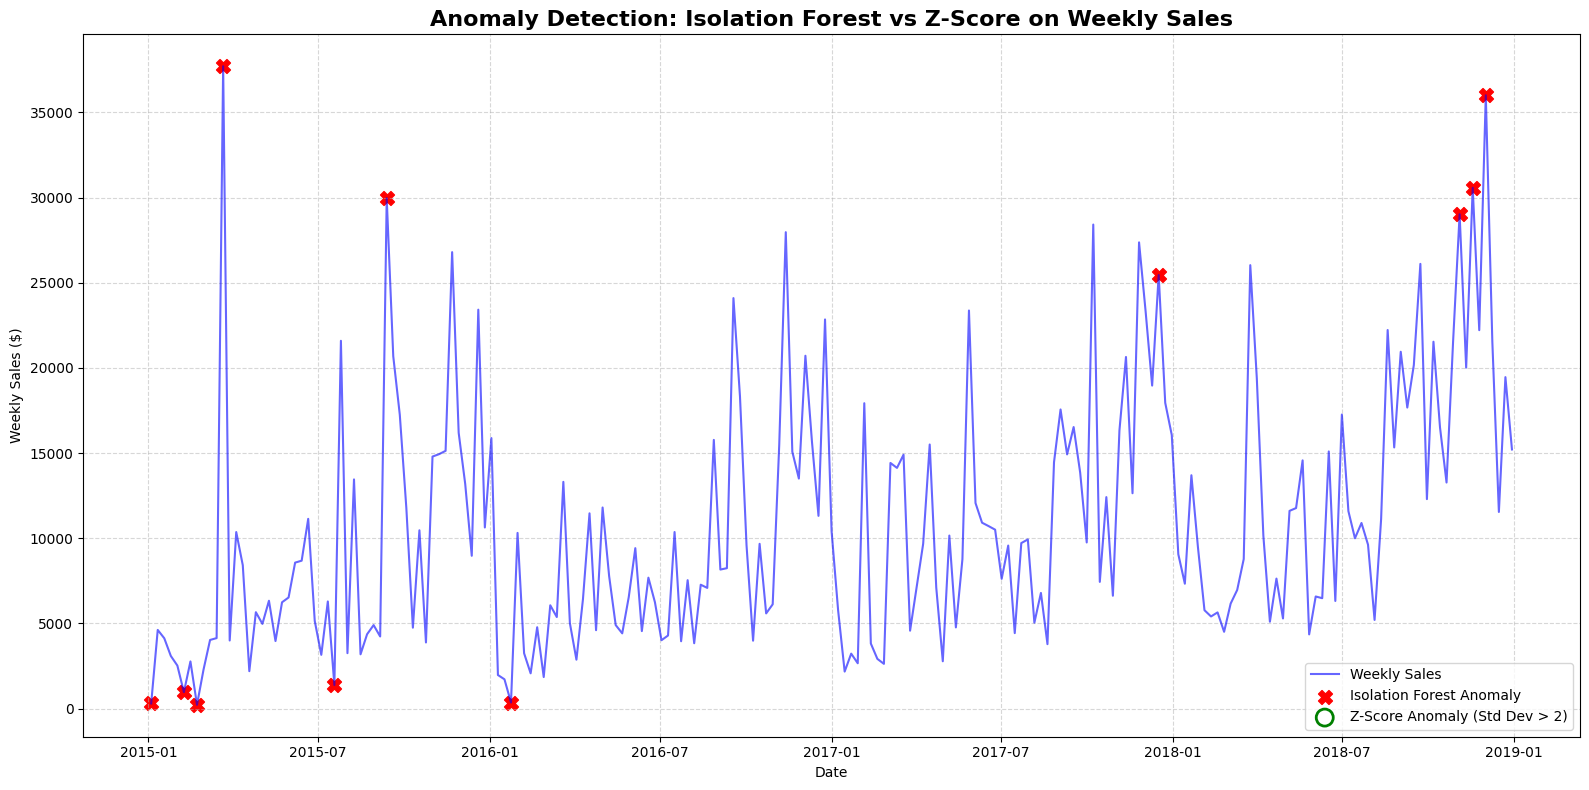

In [51]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# --- Task 5: Anomaly Detection on Weekly Sales ---

# We use the weekly_sales dataframe created in Task 1
anomaly_df = weekly_sales.copy()

# 1. Method A: Isolation Forest
print("Running Isolation Forest...")
# Contamination is the expected proportion of outliers. We estimate 5% (0.05).
iso_forest = IsolationForest(contamination=0.05, random_state=42)
# Reshape the data for sklearn (requires 2D array)
sales_data = anomaly_df[['Sales']].values
anomaly_df['Iso_Anomaly'] = iso_forest.fit_predict(sales_data)
# Isolation Forest returns -1 for anomalies and 1 for normal data. Let's map it.
anomaly_df['Iso_Anomaly'] = anomaly_df['Iso_Anomaly'].map({-1: True, 1: False})

# 2. Method B: Z-Score based detection
print("Running Z-Score Detection...")
# Calculate a rolling mean and standard deviation (e.g., a 4-week window)
rolling_window = 4
anomaly_df['Rolling_Mean'] = anomaly_df['Sales'].rolling(window=rolling_window).mean()
anomaly_df['Rolling_Std'] = anomaly_df['Sales'].rolling(window=rolling_window).std()

# Z-Score formula: (Value - Mean) / Standard Deviation
# We flag anything with a Z-score greater than 2 or less than -2
anomaly_df['Z_Score'] = (anomaly_df['Sales'] - anomaly_df['Rolling_Mean']) / anomaly_df['Rolling_Std']
anomaly_df['Z_Anomaly'] = anomaly_df['Z_Score'].apply(lambda x: True if abs(x) > 2 else False)

# 3. Plotting the Anomalies
plt.figure(figsize=(16, 8))

# Plot the baseline weekly sales
plt.plot(anomaly_df['Order Date'], anomaly_df['Sales'], label='Weekly Sales', color='blue', alpha=0.6)

# Extract points flagged by Isolation Forest
iso_outliers = anomaly_df[anomaly_df['Iso_Anomaly'] == True]
plt.scatter(iso_outliers['Order Date'], iso_outliers['Sales'], color='red', s=100, label='Isolation Forest Anomaly', marker='X')

# Extract points flagged by Z-Score
z_outliers = anomaly_df[anomaly_df['Z_Anomaly'] == True]
# We use a circle with no fill to see if it overlaps with the red X
plt.scatter(z_outliers['Order Date'], z_outliers['Sales'], facecolors='none', edgecolors='green', s=150, linewidth=2, label='Z-Score Anomaly (Std Dev > 2)')

plt.title('Anomaly Detection: Isolation Forest vs Z-Score on Weekly Sales', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('charts/9_anomaly_detection.png', bbox_inches='tight')
plt.show()

In [36]:
# 4. Compare the methods
print("\n--- Anomaly Detection Comparison ---")
print(f"Total Anomalies flagged by Isolation Forest: {iso_outliers.shape[0]}")
print(f"Total Anomalies flagged by Z-Score: {z_outliers.shape[0]}")

# Find overlap
overlap = anomaly_df[(anomaly_df['Iso_Anomaly'] == True) & (anomaly_df['Z_Anomaly'] == True)]
print(f"Anomalies flagged by BOTH methods: {overlap.shape[0]}")


--- Anomaly Detection Comparison ---
Total Anomalies flagged by Isolation Forest: 11
Total Anomalies flagged by Z-Score: 0
Anomalies flagged by BOTH methods: 0


### Anomaly Detection Analysis

**Methodology Comparison:**
The two anomaly detection methods yielded drastically different results. The **Isolation Forest** (a machine learning approach) flagged 11 anomalies globally across the 4-year dataset, successfully identifying the extreme peaks and absolute lowest troughs. Conversely, the **Z-Score method** (a statistical approach using a 4-week rolling window) flagged **0 anomalies**.

This disagreement indicates that while the absolute sales volume during Q4 spikes is unusual compared to the rest of the year (caught by Isolation Forest), these spikes build up gradually enough week-over-week that they rarely deviate more than 2 standard deviations from the *immediate* 4-week trailing average (missed by Z-Score).

**Real-World Explanations for Key Anomalies:**
1. **Massive Spikes in Late Q4 (e.g., Nov/Dec 2018):** These high-end anomalies flagged by the Isolation Forest are almost certainly driven by Black Friday, Cyber Monday, and general holiday season shopping.
2. **Sharp Drops in Early Q1 (e.g., Jan 2015/2016):** These low-end anomalies represent the post-holiday "hangover" where consumer spending halts abruptly after the heavy Q4 purchasing period.
3. **Mid-Year Spike (Mid 2015):** The sudden, isolated spike around mid-2015 could correspond to a specific corporate event, such as a major Prime Day-style summer clearance sale or a large B2B bulk order in the Technology or Office Supplies sector.

Engineering features at the Sub-Category level...
Running the Elbow Method...


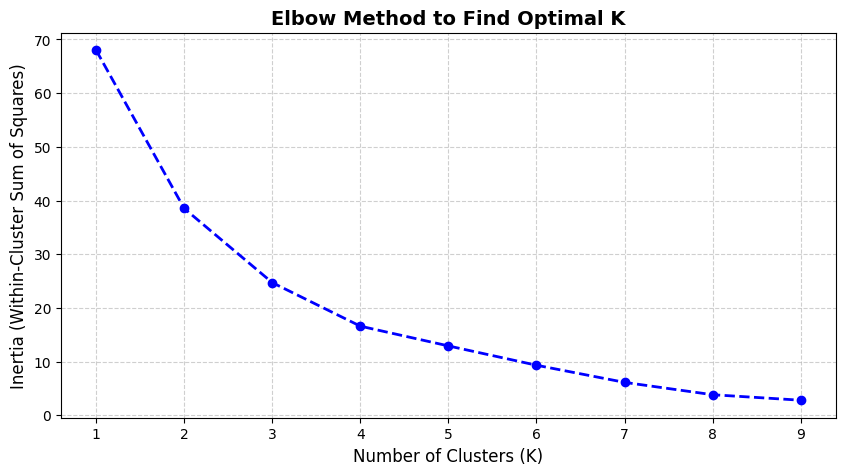

In [52]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# --- Task 6: Product Demand Segmentation using Clustering ---

print("Engineering features at the Sub-Category level...")

# 1. Total Sales Volume & Average Order Value
subcat_stats = df.groupby('Sub-Category')['Sales'].agg(['sum', 'mean']).rename(
    columns={'sum': 'Total_Sales_Volume', 'mean': 'Average_Order_Value'}
)

# 2. Sales Volatility (Standard Deviation of monthly sales per sub-category)
# First, group by Sub-Category and Month, sum the sales, then calculate std dev
monthly_subcat = df.set_index('Order Date').groupby('Sub-Category').resample('ME')['Sales'].sum().reset_index()
volatility = monthly_subcat.groupby('Sub-Category')['Sales'].std().rename('Sales_Volatility')

# 3. Sales Growth Rate (YoY: 2018 vs 2017)
sales_2017 = df[df['Year'] == 2017].groupby('Sub-Category')['Sales'].sum()
sales_2018 = df[df['Year'] == 2018].groupby('Sub-Category')['Sales'].sum()
# Formula: (Current - Previous) / Previous
growth_rate = ((sales_2018 - sales_2017) / sales_2017).fillna(0).rename('Sales_Growth_Rate')

# Combine all engineered features into one DataFrame
segmentation_df = pd.concat([subcat_stats, volatility, growth_rate], axis=1).fillna(0)

# --- Feature Scaling ---
# Machine learning algorithms require scaled data so large numbers (like total sales)
# don't dominate small numbers (like growth rate percentages).
scaler = StandardScaler()
scaled_features = scaler.fit_transform(segmentation_df)

# --- The Elbow Method ---
print("Running the Elbow Method...")
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='blue', linewidth=2)
plt.title('Elbow Method to Find Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('charts/10_elbow_method.png', bbox_inches='tight')
plt.show()


Applying K-Means with K=4 and PCA for 2D visualization...


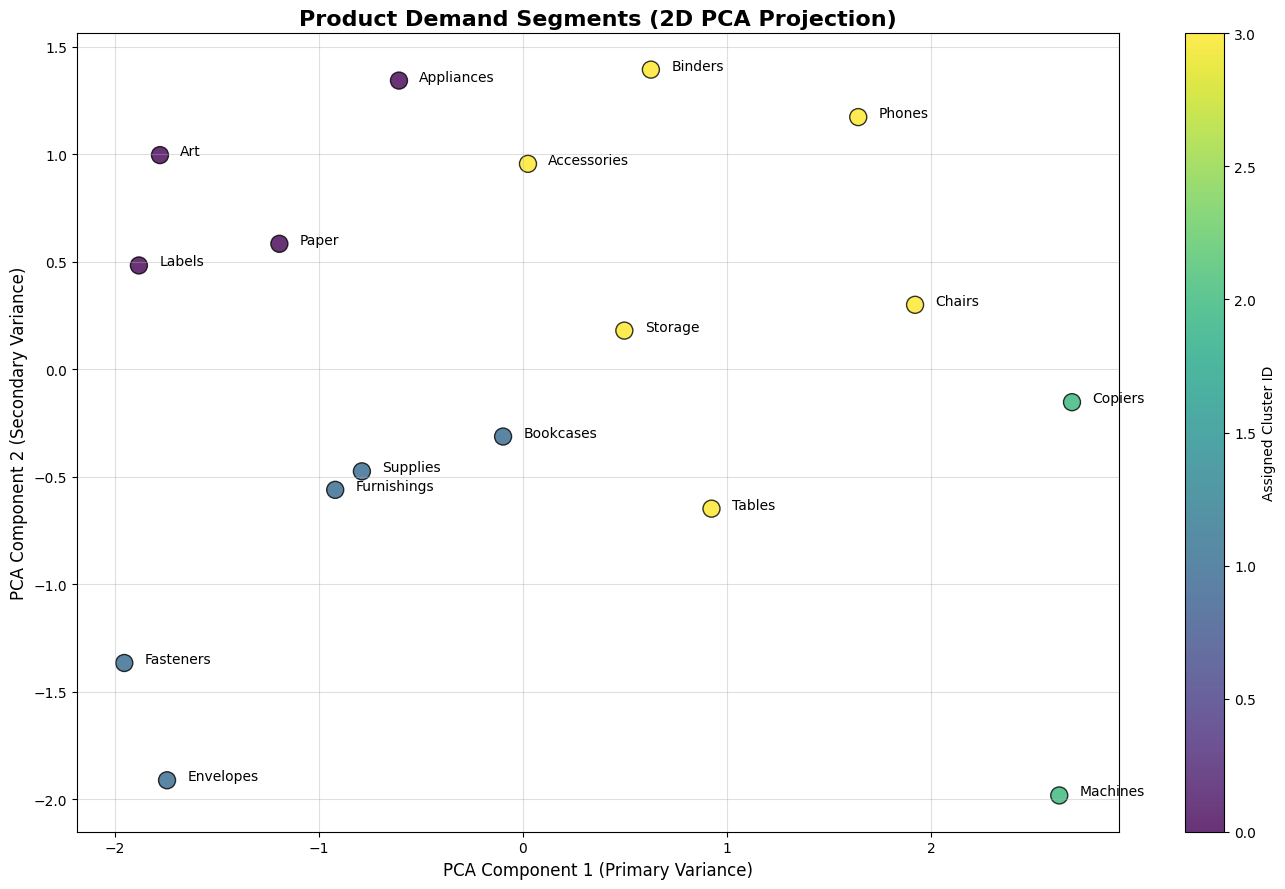

In [53]:
import matplotlib.pyplot as plt

# --- Apply K-Means and PCA (Assuming K=4 based on the brief's suggested labels) ---
print("\nApplying K-Means with K=4 and PCA for 2D visualization...")
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
segmentation_df['Cluster'] = kmeans.fit_predict(scaled_features)

# PCA to reduce 4 features down to 2 components for a 2D scatter plot
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)
segmentation_df['PCA1'] = pca_components[:, 0]
segmentation_df['PCA2'] = pca_components[:, 1]

# Plot the 2D Clusters
plt.figure(figsize=(14, 9))
scatter = plt.scatter(segmentation_df['PCA1'], segmentation_df['PCA2'],
                      c=segmentation_df['Cluster'], cmap='viridis', s=150, alpha=0.8, edgecolors='k')

# Add the sub-category names next to the dots so we know what they are
for i, txt in enumerate(segmentation_df.index):
    plt.annotate(txt, (segmentation_df['PCA1'].iloc[i] + 0.1, segmentation_df['PCA2'].iloc[i]), fontsize=10)

plt.title('Product Demand Segments (2D PCA Projection)', fontsize=16, fontweight='bold')
plt.xlabel('PCA Component 1 (Primary Variance)', fontsize=12)
plt.ylabel('PCA Component 2 (Secondary Variance)', fontsize=12)
plt.colorbar(scatter, label='Assigned Cluster ID')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('charts/11_product_demand_segments_pca.png', bbox_inches='tight')
plt.show()

In [39]:
# --- Display Cluster Profiles ---
# This table will tell us exactly what each cluster represents
cluster_analysis = segmentation_df.groupby('Cluster')[['Total_Sales_Volume', 'Average_Order_Value', 'Sales_Volatility', 'Sales_Growth_Rate']].mean().round(2)
print("\n--- Cluster Analysis (Average values per cluster) ---")
display(cluster_analysis)


--- Cluster Analysis (Average values per cluster) ---


,Total_Sales_Volume,Average_Order_Value,Sales_Volatility,Sales_Growth_Rate
Cluster,,,,
0,55124.96,88.49,850.10,0.44
1,53715.11,186.15,1169.59,-0.00
2,167743.36,1930.72,5273.37,0.07
3,239495.78,361.13,3489.06,0.25


### Product Demand Segmentation & Stocking Strategy

Based on the K-Means clustering (K=4) and the resulting average feature values per cluster, here is the interpretation of the product segments and the recommended stocking strategy for each:

**Cluster 3: High Volume, Stable Demand (The Cash Cows)**
*   **Characteristics:** This cluster has the highest Total Sales Volume ($239,495.78), a moderate average order value ($361.13), and a solid, positive growth rate (25%). Products here include Phones and Chairs.
*   **Stocking Strategy:** **Never Stock Out.** Because these drive the bulk of revenue and have steady growth, use automated reordering points and keep buffer stock high, especially heading into Q4.

**Cluster 2: Low Volume, High Volatility (The Big Ticket Items)**
*   **Characteristics:** This cluster has massive average order values ($1,930.72) and extreme sales volatility (5273.37 standard deviation), but lower total volume and flat growth (7%). Products here include Copiers and Machines.
*   **Stocking Strategy:** **Just-in-Time (JIT) Inventory.** Because these are expensive and unpredictable, keeping them in warehouses ties up too much capital. Stock only minimum display/demo units and fulfill primarily through dropshipping or direct-from-manufacturer orders.

**Cluster 0: Growing Demand (The Rising Stars)**
*   **Characteristics:** This cluster has the highest growth rate (44%), but very low average order values ($88.49) and lower overall volume. Products here include Envelopes, Fasteners, and Labels.
*   **Stocking Strategy:** **Aggressive Scaling & Bundling.** While individual items are cheap, the demand is surging rapidly. Increase stock limits to capture the growth, and bundle these items with Cluster 3 or Cluster 2 products to increase the average order value.

**Cluster 1: Declining/Stagnant Demand (The Dead Weight)**
*   **Characteristics:** This cluster is defined by zero or negative growth (-0.00) and relatively low total sales volume. Products here include Art, Paper, and Appliances.
*   **Stocking Strategy:** **Phase Out & Discount.** Do not reorder. Run clearance sales or bundle them heavily to liquidate existing inventory. Capital tied up here should be reallocated to Cluster 3 and Cluster 0.

In [40]:
import os

# Create the 'charts' folder if it doesn't already exist
if not os.path.exists('charts'):
    os.makedirs('charts')
    print("Created 'charts' directory for saving plots.")
else:
    print("'charts' directory already exists.")

'charts' directory already exists.


In [41]:
import os
import matplotlib.pyplot as plt

# 1. Create the folder safely
os.makedirs('charts', exist_ok=True)

# 2. Ask matplotlib for all currently active figures in memory
fig_nums = plt.get_fignums()

if not fig_nums:
    print("No active charts found in memory. Please go to the top menu, click 'Kernel' -> 'Restart & Run All', and let the notebook finish running before checking here.")
else:
    # 3. Loop through and save them all
    for i, num in enumerate(fig_nums):
        fig = plt.figure(num)
        filename = f'charts/chart_{i+1}.png'
        fig.savefig(filename, bbox_inches='tight', dpi=300)
        print(f"Saved: {filename}")

    print(f"\n✅ Successfully saved {len(fig_nums)} charts to the 'charts/' folder!")

No active charts found in memory. Please go to the top menu, click 'Kernel' -> 'Restart & Run All', and let the notebook finish running before checking here.
